# First Project

## Introduction
This notebook contains the computational solutions of a mini project conducted in the University of Crete for the course of Mathematical Seismology. It explores 1D wave equations with point sources, Semi-Infinite Medium via Odd Extension in Elastic Media.

### Problem Statement
Solve the following wave differential equation:
$$u_{xx}-2u_{tt}-\delta(x-1)\delta(t)+\delta(x+1)\delta(t-1)=0, \quad x \in \mathbb{R}, \quad t \ge 0$$

### Initial Conditions: 

Initial Displacement: $u(x,0) = H(x+2) - H(x)$

Initial Velocity: $u_t(x,0) = \delta(x+1)$

Objective:
Create an animation of the displacement at points $x \in [-10, 10]$ for time $t \in [0, 4]$ s.

## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import pandas as pd

## First Case

In [2]:
tmax = 4
c = np.sqrt(2)/2
x = np.linspace(-10,10,1024)
t = np.linspace(0,tmax,30*tmax)

def H(t):
    h = np.zeros(len(t))
    for i, it in enumerate(t):
        if it > 0:
            h[i]=1
        else:
            h[i]=0.0
    return h

### Indicator functions

In [3]:
def indicatorfunc1(x):
  L=pd.Interval(left=-10,right=10 + 2*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0
def indicatorfunc2(x):
  L=pd.Interval(left=-10 + np.sqrt(2)/2,right=10 + (3/2)*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0

### Functions

In [4]:
def f1(x,t): 
    return (H(x - t*c +2)-H(x - t*c))/2
def f2(x,t): 
    return (H(x + t*c +2)-H(x + t*c))/2
def G(x,t):
    return (1/np.sqrt(2))*indicatorfunc1(-1)
def F1(x,t):
    return -((np.sqrt(2))/4)*indicatorfunc1(1)
def F2(x,t):
    return ((np.sqrt(2))/4)*indicatorfunc2(-1)

### Plotting the animation

MovieWriter ffmpeg unavailable; using Pillow instead.


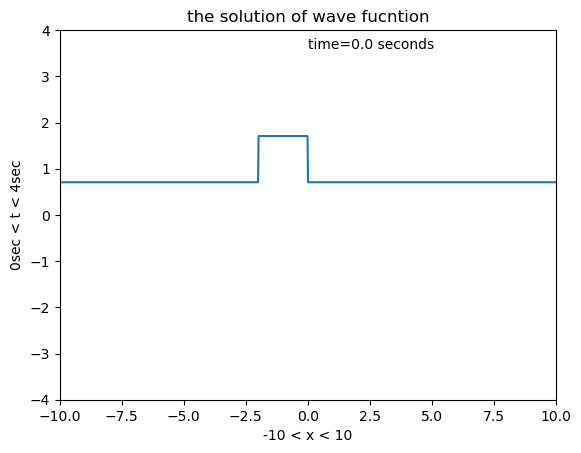

In [5]:
fig = plt.figure()
ax = plt.axes(xlim=(x[0], x[-1]), ylim=(-4, 4))
time_text = ax.text(0.5,0.98,'',ha='left',va='top',transform=ax.transAxes)
instance, = ax.plot([], [])
plt.title('the solution of wave fucntion')
plt.xlabel('-10 < x < 10') 
plt.ylabel('0sec < t < 4sec')
def update_data(t):
    instance.set_data(x, f1(x,t)+f2(x,t)+G(x,t)+F1(x,t)+F2(x,t))
    time_format='time={0:0.1f} seconds'
    time_text.set_text(time_format.format(t))
    return instance,

anim = animation.FuncAnimation(fig, update_data, frames=t, repeat=False, interval=30., blit=False)
anim.save('1.gif', fps=30)

## Second Case

### Problem Statement:
In this case, we solve the wave equation from the First Case with the spatial constraint $x \ge 0$. To satisfy the Dirichlet boundary condition ($u(0, t) = 0$) at the origin, we apply an odd extension to the initial conditions and the source terms.

Objective:
Animate the displacement for the range $x \in [-10, 10]$ over the time interval $t \in [0, 4]$ s to observe the reflection at the boundary.

In [6]:
tmax = 4
c = np.sqrt(2)/2
x = np.linspace(0,10,128)
t = np.linspace(0,tmax,30*tmax)

def H(t):
    h = np.zeros(len(t))
    for i, it in enumerate(t):
        if it > 0:
            h[i]=1
        else:
            h[i]=0.0
    return h

### Indicators 

In [7]:
def indicatorfunc1(x):
  L=pd.Interval(left=-10,right=10 + 2*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0
def indicatorfunc2(x):
  L=pd.Interval(left=-10 + np.sqrt(2)/2,right=10 + (3/2)*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0
def indicatorfunc3(x):
  L=pd.Interval(left=-10,right=0)
  if x in L:
      return 1
  else:
      return 0
def indicatorfunc4(x):
  L=pd.Interval(left=0,right=10 + 2*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0  
def indicatorfunc5(x):
  L=pd.Interval(left=-10 +np.sqrt(2)/2,right=0)
  if x in L:
      return 1
  else:
      return 0  
def indicatorfunc6(x):
  L=pd.Interval(left=0,right=10 +(3/2)*np.sqrt(2))
  if x in L:
      return 1
  else:
      return 0 

### Writing the analytical solutions as functions for plotting.

In [8]:
def f1(x,t): 
    return (H(x - t*c +2)-H(x - t*c))/2
def f2(x,t): 
    return (H(x + t*c +2)-H(x + t*c))/2
def G(x,t):
    return (1/np.sqrt(2))*indicatorfunc1(-1)
def F1(x,t):
    return indicatorfunc1(1)
def F2(x,t):
    return indicatorfunc2(-1)
def f3(x,t): 
    return (-H(x - t*c +2)+H(x - t*c))/2
def f4(x,t): 
    return (H(x + t*c +2)-H(x + t*c))/2
def G1(x,t):
    return (-1/np.sqrt(2))*indicatorfunc3(-1)
def G2(x,t):
    return (1/np.sqrt(2))*indicatorfunc4(-1)
def F3(x,t):
    return indicatorfunc3(1)
def F4(x,t):
    return -indicatorfunc4(1)    
def F5(x,t):
    return -indicatorfunc5(-1)
def F6(x,t):
    return indicatorfunc6(-1)

### Plotting the animation.

MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.


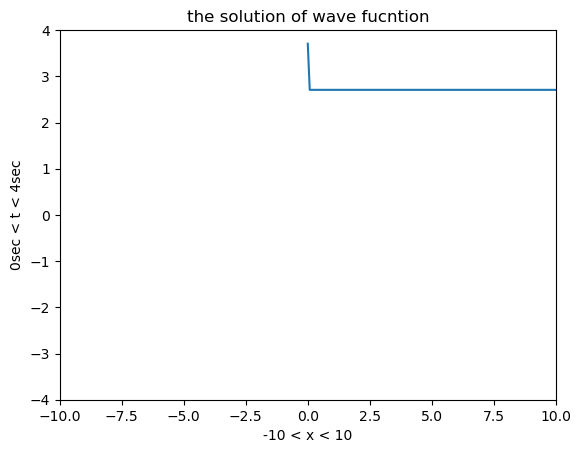

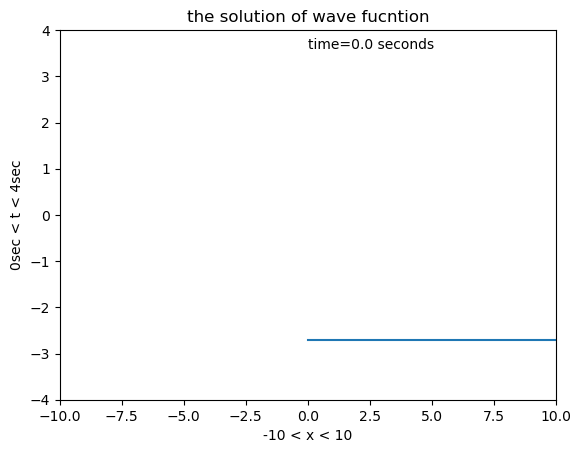

In [9]:
fig1 = plt.figure()
ax1 = plt.axes(xlim=(-10,10), ylim=(-4, 4))
time_text = ax1.text(0.5,0.98,'',ha='left',va='top',transform=ax1.transAxes)
instance1, = ax1.plot([], [])
plt.title('the solution of wave fucntion')
plt.xlabel('-10 < x < 10') 
plt.ylabel('0sec < t < 4sec')
def update_data1(t):
    instance1.set_data(x, f1(x,t)+f2(x,t)+G(x,t)+F1(x,t)+F2(x,t))
    time_format='time={0:0.1f} seconds'
    time_text.set_text(time_format.format(t))
    return instance1,

fig2 = plt.figure()
ax2 = plt.axes(xlim=(-10,10), ylim=(-4, 4))
time_text = ax2.text(0.5,0.98,'',ha='left',va='top',transform=ax2.transAxes)
instance2, = ax2.plot([], [])
plt.title('the solution of wave fucntion')
plt.xlabel('-10 < x < 10') 
plt.ylabel('0sec < t < 4sec')

def update_data2(t):
    instance2.set_data(x,f3(x,t)+f4(x,t)+G1(x,t)+G2(x,t)+F3(x,t)+F4(x,t)+F5(x,t)+F6(x,t))
    time_format='time={0:0.1f} seconds'
    time_text.set_text(time_format.format(t))
    return instance2,

anim1 = animation.FuncAnimation(fig1, update_data1, frames=t, repeat=False, interval=30., blit=False)
anim1.save('2.gif', fps=30)

anim2 = animation.FuncAnimation(fig2, update_data2, frames=t, repeat=False, interval=30., blit=False)
anim2.save('3.gif', fps=30)